# Analiza zbioru Heart Disease - Regresja Logistyczna

**Imię i Nazwisko:** Krystian Osak
**Numer indeksu:** 94803
**Grupa:** Regresja Logistyczna (ostatnia cyfra indeksu: 3)

## 1. Wstęp i załadowanie danych
Celem tego zadania jest klasyfikacja pacjentów pod kątem obecności choroby serca na podstawie danych medycznych ze zbioru UCI Heart Disease. Zbiór ten zawiera wartości brakujące oraz cechy kategoryczne, co wymaga odpowiedniego przygotowania danych (tzw. preprocessingu) przed podaniem ich do modelu.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
import warnings

warnings.filterwarnings('ignore')

def load_and_clean_data(url):
    """Pobiera dane, nadaje nazwy kolumnom i zamienia '?' na NaN."""
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
               'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    df = pd.read_csv(url, names=columns, na_values='?')
    return df

def preprocess_data(df):
    """
    Radzenie sobie z brakami danych (imputacja medianą)
    oraz kodowanie zmiennych kategorycznych (One-Hot Encoding).
    """
    df_clean = df.copy()

    df_clean['ca'].fillna(df_clean['ca'].median(), inplace=True)
    df_clean['thal'].fillna(df_clean['thal'].median(), inplace=True)

    categorical_cols = ['cp', 'restecg', 'slope', 'thal']
    df_clean[categorical_cols] = df_clean[categorical_cols].astype(str)
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

    df_clean['target'] = (df_clean['target'] > 0).astype(int)

    return df_clean

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df_raw = load_and_clean_data(url)

## 2. Wstępna analiza danych (EDA)
Przed wrzuceniem danych do modelu muszę sprawdzić, z czym w ogóle mamy do czynienia. Na start weryfikuję trzy najważniejsze rzeczy:
* czy mamy jakieś braki w danych (tzw. NaNy, które wywalą błąd w modelu),
* czy klasy są zbalansowane (czyli czy w zbiorze jest mniej więcej tyle samo osób chorych co zdrowych),
* jak rozkłada się wiek pacjentów.## 2. Analiza zbioru danych (EDA)
Zanim przejdziemy do uczenia modelu, zbadamy rozkład naszych danych. Sprawdzimy m.in.:
* Czy zbiór posiada braki danych (NaN).
* Jak wygląda zbalansowanie klas (czy mamy tyle samo osób chorych co zdrowych).
* Jak rozkłada się wiek pacjentów.

--- PODSTAWOWE INFORMACJE O ZBIORZE ---
Liczba wierszy: 303, Liczba kolumn: 14

Liczba brakujących danych w poszczególnych kolumnach:
ca      4
thal    2
dtype: int64


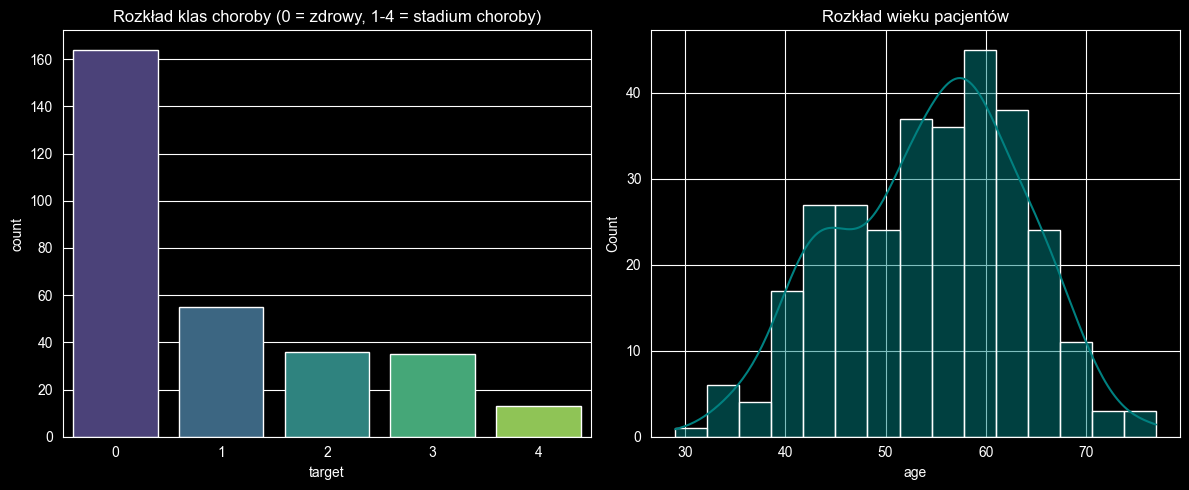


Rozmiar zbioru po One-Hot Encodingu: (303, 19)


In [2]:
print("--- PODSTAWOWE INFORMACJE O ZBIORZE ---")
print(f"Liczba wierszy: {df_raw.shape[0]}, Liczba kolumn: {df_raw.shape[1]}")
print("\nLiczba brakujących danych w poszczególnych kolumnach:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='target', data=df_raw, ax=axes[0], palette='viridis')
axes[0].set_title('Rozkład klas choroby (0 = zdrowy, 1-4 = stadium choroby)')

sns.histplot(df_raw['age'], bins=15, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Rozkład wieku pacjentów')

plt.tight_layout()
plt.show()

df_processed = preprocess_data(df_raw)
print(f"\nRozmiar zbioru po One-Hot Encodingu: {df_processed.shape}")

## 3. Teoria: Jak działa Regresja Logistyczna?
W tym zadaniu padło na **Regresję Logistyczną**.

**Co to robi?**
Algorytm bierze wszystkie cechy pacjenta, wrzuca je do jednego równania i na koniec przepuszcza przez krzywą w kształcie S. Dzięki temu z dowolnych liczb robi nam się wynik od 0 do 1, który możemy potraktować jako **prawdopodobieństwo**. Jeśli wynik wyjdzie powyżej 0.5 – algorytm uznaje, że pacjent jest chory (klasa 1). Jeśli poniżej – uznaje go za zdrowego (klasa 0).

**Parametr `C`**
W kolejnym kroku sprawdzamy, jak na jakość modelu wpływa parametr `C`. Najłatwiej myśleć o nim jako o suwaku, który kontroluje **zaufanie modelu do szczegółów** z danych treningowych:
* **Małe `C`** = ograniczone zaufanie. Model skupia się wyłącznie na najsilniejszych, ogólnych trendach i ignoruje drobne różnice. Jeśli przesadzimy, model będzie zbyt ogólny i niedouczony (underfitting).
* **Duże `C`** = pełne zaufanie. Model stara się wyłapać każdy, nawet najmniejszy detal. Często kończy się to tym, że uczy się danych "na pamięć" (overfitting) i gubi się, gdy dostanie przypadek nowego pacjenta. Naszym celem jest znalezienie tutaj złotego środka.

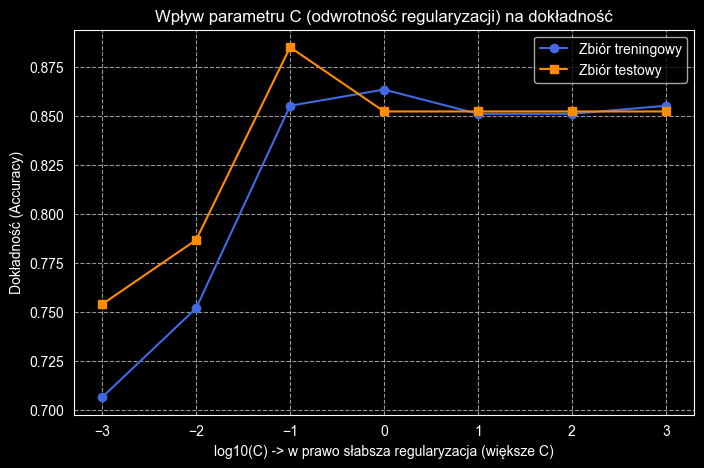

In [4]:
X = df_processed.drop('target', axis=1)

X = X.fillna(X.median())

y = df_processed['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def run_experiments(X_train, X_test, y_train, y_test):
    """Bada wpływ parametru C na dokładność modelu."""
    C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    train_accuracies = []
    test_accuracies = []

    for c in C_values:
        model = LogisticRegression(C=c, max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        train_accuracies.append(accuracy_score(y_train, model.predict(X_train)))
        test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

    return C_values, train_accuracies, test_accuracies

C_vals, train_acc, test_acc = run_experiments(X_train, X_test, y_train, y_test)

plt.figure(figsize=(8, 5))
plt.plot(np.log10(C_vals), train_acc, label='Zbiór treningowy', marker='o', color='royalblue')
plt.plot(np.log10(C_vals), test_acc, label='Zbiór testowy', marker='s', color='darkorange')
plt.title('Wpływ parametru C (odwrotność regularyzacji) na dokładność')
plt.xlabel('log10(C) -> w prawo słabsza regularyzacja (większe C)')
plt.ylabel('Dokładność (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Wnioski z eksperymentu:**
Na wykresie widzimy zależność dokładności od parametru `C` (oś X w skali logarytmicznej). Zbyt małe wartości `C` (lewa strona) powodują niedouczenie modelu (zbyt silna regularyzacja), co widać po niższej dokładności. Wraz ze wzrostem parametru, dokładność na zbiorze testowym rośnie, osiągając szczyt i stabilizując się w okolicach wartości C=1. Jako optymalny parametr dla naszego ostatecznego modelu wybieramy więc `C=1`.

## 4. Ostateczny model i Krzywa ROC
Na koniec wytrenujemy model z optymalnym parametrem i wykreślimy **krzywą ROC**. Pokazuje ona zdolność modelu do odróżniania klas (chory/zdrowy) przy różnych progach decyzyjnych. Pole pod tą krzywą, czyli **AUC**, to doskonała miara jakości modelu binarnego – im wartość bliższa 1.0, tym lepiej model radzi sobie z diagnozą.

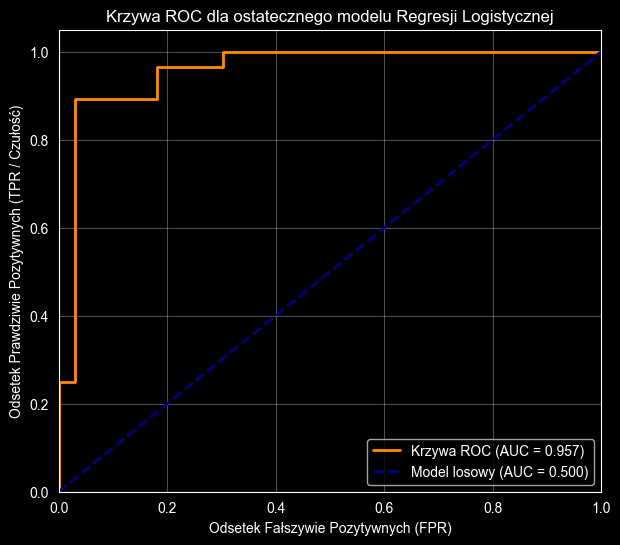

In [5]:
def plot_roc_curve(model, X_test, y_test):
    """Oblicza i rysuje krzywą ROC oraz pole AUC."""
    y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Krzywa ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Model losowy (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Odsetek Fałszywie Pozytywnych (FPR)')
    plt.ylabel('Odsetek Prawdziwie Pozytywnych (TPR / Czułość)')
    plt.title('Krzywa ROC dla ostatecznego modelu Regresji Logistycznej')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

best_model = LogisticRegression(C=1, max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

plot_roc_curve(best_model, X_test, y_test)